Collect the bounding boxes of all y-labels, and move the left border of the subplot to the right so that it leaves enough room for the union of all the bounding boxes.

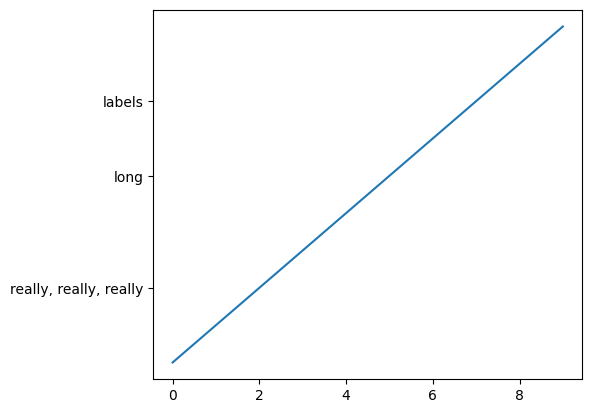

In [4]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

fig, ax = plt.subplots()
ax.plot(range(10))
ax.set_yticks([2, 5, 7], labels=["really, really, really", "long", "labels"])


def on_draw(event):
    bboxes = []

    for label in ax.get_yticklabels():
        # bounding box in pixels in display units
        bbox_px = label.get_window_extent()

        # Transform the display units to relative figure coordinates.
        # This is the inverse of transFigure.
        bbox_fig = bbox_px.transformed(fig.transFigure.inverted())
        bboxes.append(bbox_fig)

    # The bbox that bounds all the bboxes, again in relative figure coords
    bbox = mtransforms.Bbox.union(bboxes)

    if fig.subplotpars.left < bbox.width:
        # Move the subplot's left edge, more to the right
        fig.subplots_adjust(left=1.1 * bbox.width)  # pad a little
        fig.canvas.draw()


fig.canvas.mpl_connect("draw_event", on_draw)
plt.show()